#Neste projeto, a variável GradeClass foi escolhida como variável alvo (target) por representar diretamente o desempenho acadêmico final dos estudantes. Diferentemente das demais variáveis do dataset, que descrevem características dos alunos — como tempo de estudo, número de faltas, apoio dos pais e participação em atividades extracurriculares — a GradeClass corresponde ao resultado que desejamos prever.

#Além disso, GradeClass já possui categorias definidas que representam diferentes níveis de desempenho acadêmico:

#* 0 = A (GPA ≥ 3.5)
#* 1 = B (3.0 ≤ GPA < 3.5)
#* 2 = C (2.5 ≤ GPA < 3.0)
#* 3 = D (2.0 ≤ GPA < 2.5)
#* 4 = F (GPA < 2.0)

#Como o objetivo do Aprendizado Supervisionado é aprender a relação entre variáveis explicativas e uma resposta conhecida, a GradeClass é uma escolha adequada por funcionar como o rótulo (label) que o modelo deverá prever. Dessa forma, a Rede Neural será treinada para identificar padrões nas características dos estudantes e classificá-los em uma das cinco categorias de desempenho.

#Do ponto de vista de Machine Learning, este problema é caracterizado como uma tarefa de classificação multiclasse, pois existem mais de duas classes possíveis de saída (A, B, C, D e F). O objetivo do modelo será estimar a probabilidade de cada aluno pertencer a cada uma dessas classes e selecionar aquela com maior probabilidade como previsão final.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.graph_objs as go
from sklearn.cluster import KMeans
import warnings
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV, GridSearchCV, train_test_split

#from pandasql import sqldf
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pwd
!ls /content/drive

/content
MyDrive  Othercomputers


In [4]:
!ls '/content/drive/MyDrive/PROFISSIONAL/Projetos Pessoais/Machine_Learning_Students/data/Student_performance_data _.csv'
caminho='/content/drive/MyDrive/PROFISSIONAL/Projetos Pessoais/Machine_Learning_Students/data/Student_performance_data _.csv'

'/content/drive/MyDrive/PROFISSIONAL/Projetos Pessoais/Machine_Learning_Students/data/Student_performance_data _.csv'


In [5]:
df = pd.read_csv(caminho)

print(df.columns)

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')


In [6]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


# Target = GradeClass

# Quantos alunos existem em cada classe (A, B, C, D e F)

In [7]:
df['GradeClass'].value_counts().sort_index()

,count
GradeClass,
0.0,107
1.0,269
2.0,391
3.0,414
4.0,1211


# 1 - Separação das Variáveis Explicativas (X) e da Variável Alvo (y)

###* X (features): variáveis que serão utilizadas para realizar as previsões (Informação que você fornece ao modelo)
###* y (target): variável que contém as respostas corretas que o modelo deverá aprender _ O que você quer que ele aprenda a prever! (GradeClass)

In [8]:
# Variáveis explicativas
X = df.drop(columns=['GradeClass'])

# Variável alvo
y = df['GradeClass']

In [9]:
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

display(X.head())
display(y.head())

Dimensão de X: (2392, 14)
Dimensão de y: (2392,)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061


,GradeClass
0,2.0
1,1.0
2,4.0
3,3.0
4,4.0


#2 - Divisão dos Dados em Treino e Teste

###Agora que já separamos:

###* X → características dos alunos
###* y → GradeClass (Target)

###Precisamos ensinar a Rede Neural

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Train = Usado para ensinar o modelo.
### Test = Usado para avaliar o modelo.

In [11]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1913, 14)
X_test: (479, 14)
y_train: (1913,)
y_test: (479,)


| Variável | Função                                            |
| -------- | ------------------------------------------------- |
| X_train  | Características para ensinar a rede               |
| y_train  | Respostas corretas para ensinar a rede            |
| X_test   | Características para avaliar a rede               |
| y_test   | Respostas corretas para comparar com as previsões |


# 3 - Preparação das Features (Removendo GradeClass e GPA)

###Primeiro criamos o conjunto de entrada (X) removendo:

### * GradeClass → porque é o alvo
### * GPA → para evitar vazamento de dados

In [12]:
X = df.drop(columns=['GradeClass', 'GPA'])

y = df['GradeClass']

##A variável GPA foi removida da análise para evitar vazamento de dados (data leakage), pois a GradeClass é definida diretamente a partir do GPA. Mantê-la no modelo faria com que a Rede Neural tivesse acesso à própria informação utilizada para gerar a resposta, produzindo resultados artificialmente elevados e pouco realistas.

In [13]:
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (2392, 13)
Shape de y: (2392,)


In [14]:
display(X.head())
display(y.head())

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0


,GradeClass
0,2.0
1,1.0
2,4.0
3,3.0
4,4.0


## Em resumo, ensinamos o computador:

###"Você pode olhar para as características dos alunos, mas não pode olhar para o GPA. Tente descobrir sozinho quais características levam um aluno a ter nota A, B, C, D ou F."

#4 — Transformação das Variáveis Categóricas (One-Hot Encoding)

###Após definir as variáveis de entrada (X) e a variável alvo (y), o próximo passo é transformar as variáveis categóricas em formato numérico. Essa etapa é necessária porque Redes Neurais realizam cálculos matemáticos e não conseguem interpretar diretamente categorias ou textos.

###EX: (Após o One-Hot Encoding:)

| Gender_Male | Gender_Female |
| ----------- | ------------- |
| 1           | 0             |
| 0           | 1             |


In [15]:
X = pd.get_dummies(
    X,
    columns=[
        'Gender',
        'Ethnicity',
        'ParentalEducation',
        'ParentalSupport'
    ],
    drop_first=False
)

### Rename Categorical Variables

In [16]:
rename_mapping = {

    # Gender
    'Gender_0': 'Male',
    'Gender_1': 'Female',

    # Ethnicity
    'Ethnicity_0': 'Caucasian',
    'Ethnicity_1': 'African_American',
    'Ethnicity_2': 'Asian',
    'Ethnicity_3': 'Other_Ethnicity',

    # Parental Education
    'ParentalEducation_0': 'ParentalEd_None',
    'ParentalEducation_1': 'ParentalEd_High_School',
    'ParentalEducation_2': 'ParentalEd_Some_College',
    'ParentalEducation_3': 'ParentalEd_Bachelors',
    'ParentalEducation_4': 'ParentalEd_Higher',

    # Tutoring
    'Tutoring_0': 'No_Tutoring',
    'Tutoring_1': 'Yes_Tutoring',

    # Parental Support
    'ParentalSupport_0': 'ParentalSup_None',
    'ParentalSupport_1': 'ParentalSup_Low',
    'ParentalSupport_2': 'ParentalSup_Moderate',
    'ParentalSupport_3': 'ParentalSup_High',
    'ParentalSupport_4': 'ParentalSup_Very_High',

    # Extracurricular
    'Extracurricular_0': 'No_Extracurricular',
    'Extracurricular_1': 'Yes_Extracurricular',

    # Sports
    'Sports_0': 'No_Sports',
    'Sports_1': 'Yes_Sports',

    # Music
    'Music_0': 'No_Music',
    'Music_1': 'Yes_Music',

    # Volunteering
    'Volunteering_0': 'No_Volunteering',
    'Volunteering_1': 'Yes_Volunteering'
}

X = X.rename(columns=rename_mapping)

In [17]:
print(X.shape)
display(X.iloc[:10, :11])


(2392, 25)


,StudentID,Age,StudyTimeWeekly,Absences,Tutoring,Extracurricular,Sports,Music,Volunteering,Male,Female
0,1001,17,19.833723,7,1,0,0,1,0,False,True
1,1002,18,15.408756,0,0,0,0,0,0,True,False
2,1003,15,4.210570,26,0,0,0,0,0,True,False
3,1004,17,10.028829,14,0,1,0,0,0,False,True
4,1005,17,4.672495,17,1,0,0,0,0,False,True
5,1006,18,8.191219,0,0,1,0,0,0,True,False
6,1007,15,15.601680,10,0,0,1,0,0,True,False
7,1008,15,15.424496,22,1,1,0,0,0,False,True
8,1009,17,4.562008,1,0,0,1,0,1,True,False
9,1010,16,18.444466,0,0,1,0,0,0,False,True


#5 — Nova Divisão entre Treino e Teste

### Agora que as variáveis categóricas já foram transformadas em colunas numéricas, vamos criar os conjuntos de treino e teste que serão utilizados pela Rede Neural.

###A partir daqui:

###X_train será usado para ensinar a Rede Neural.
###X_test será usado para verificar se ela consegue prever alunos que nunca viu.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1913, 25)
X_test: (479, 25)
y_train: (1913,)
y_test: (479,)


### Logo, criamos:

| Variável | Função                                |
| -------- | ------------------------------------- |
| X_train  | Dados para ensinar a Rede Neural      |
| y_train  | Respostas corretas para o treinamento |
| X_test   | Dados nunca vistos pela Rede Neural   |
| y_test   | Respostas corretas para avaliação     |


#6 — Padronização dos Dados com StandardScaler

### Agora que os dados já estão separados em treino e teste, precisamos colocá-los na mesma escala.

### Caso não façamos isso, a Rede Neural pode dar mais importância para variáveis com números maiores, mesmo que elas não sejam mais importantes.

###EX:
###Age varia aproximadamente entre 15 e 18  / Absences varia entre 0 e 30


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [21]:
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [22]:
print(X_train.shape)
print(X_test.shape)

(1913, 25)
(479, 25)


Transformamos todas as variáveis para uma escala comum, evitando que características com valores maiores tenham influência desproporcional durante o treinamento da Rede Neural.

#7 — Construção da Arquitetura da Rede Neural

O que é uma arquitetura?

A arquitetura define:

*   Quantas camadas a rede terá.
*   Quantos neurônios existirão em cada camada.
*   Como as informações vão fluir até a previsão final

#### Fluxo

1. Características do aluno - 25 colunas
2. Camada Oculta 1 (32 neurônios)
3. Camada Oculta 2 (16 neurônios)
4. Camada de Saída (5 neurônios)



In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Sequential

* Permite criar uma rede camada por camada.

Dense

* Cria uma camada totalmente conectada de neurônios.

## Criando o modelo

In [24]:
model = Sequential()

## Primeira camada oculta

In [25]:
model.add(
    Dense(
        32,
        activation='relu',
        input_shape=(X_train.shape[1],) # Define quantas entradas existem.
    )
)

32 Neurônios

Cada neurônio tentará aprender padrões diferentes dos alunos.

## Segunda camada oculta

In [26]:
model.add(
    Dense(
        16,
        activation='relu'
    )
)

Essa camada recebe os padrões encontrados pela primeira camada e tenta refiná-los.

##Camada de saída

Lembre-se:

* 0 = A
* 1 = B
* 2 = C
* 3 = D
* 4 = F

In [27]:
# Logo, nós temos 5 classes
model.add(
    Dense(
        5,
        activation='softmax'
    )
)

Usamos 5 neurônios, para calcular a probabilidade de cada classe.

### Visualizando a arquitetura

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,445 (5.64 KB)

 Trainable params: 1,445 (5.64 KB)

 Non-trainable params: 0 (0.00 B)

* dense     → primeira camada oculta
* dense_1   → segunda camada oculta
* dense_2   → camada de saída

### Resumo da Criação da Rede Neural

Criamos a estrutura física da Rede Neural.

Ela possui:

*  25 entradas (Colunas = características)
*  32 neurônios na primeira camada
*  16 neurônios na segunda camada
*  5 neurônios na saída

Mas ela ainda não sabe prever nada.


# 8 - Compilar

In [29]:
# 2 - Compilar
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

| Linha                                    | Função                                               |
| ---------------------------------------- | ---------------------------------------------------- |
| `optimizer='adam'`                       | Define como a rede corrige seus erros                |
| `loss='sparse_categorical_crossentropy'` | Mede o tamanho do erro                               |
| `metrics=['accuracy']`                   | Mede quantos alunos foram classificados corretamente |


# 9 — Treinamento da Rede Neural
### Agora precisamos mostrar exemplos para ela aprender.

In [30]:
history = model.fit(
    X_train,
    y_train,
    epochs=50, # é uma passagem completa pelos dados. (A rede estudará os mesmos alunos 50 vezes.)
    batch_size=32, # A rede não analisa todos os alunos de uma vez. (32 alunos por vez)
    validation_split=0.2 # 20% → validação (A validação serve para verificar se a rede está aprendendo ou apenas decorando.)
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3752 - loss: 1.5293 - val_accuracy: 0.4856 - val_loss: 1.3998
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5105 - loss: 1.3319 - val_accuracy: 0.5091 - val_loss: 1.2691
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5418 - loss: 1.1942 - val_accuracy: 0.5509 - val_loss: 1.1512
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5797 - loss: 1.0737 - val_accuracy: 0.5875 - val_loss: 1.0546
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6216 - loss: 0.9802 - val_accuracy: 0.6345 - val_loss: 0.9914
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6444 - loss: 0.9167 - val_accuracy: 0.6710 - val_loss: 0.9544
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6725 - loss: 0.8705 - val_accuracy: 0.6632 - val_loss: 0.9335
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6745 - loss: 0.8369 - val_accuracy: 0.6658 - val_loss:

* loss → quanto a rede está errando.
* accuracy → quantos alunos ela está acertando.
* val_loss → erro na validação.
* val_accuracy → acerto na validação.

#10 — Avaliação da Rede Neural

###Agora que a Rede Neural foi treinada, precisamos responder à pergunta mais importante do projeto:

###A rede consegue prever corretamente a classificação de alunos que ela nunca viu?

In [31]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Loss:", loss)
print("Accuracy:", accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6848 - loss: 0.8206
Loss: 0.8206139802932739
Accuracy: 0.6847599148750305


*  Accuracy = quantos acertou
*  Loss = quão erradas foram as previsões

O que acabamos de fazer?

Medimos o desempenho real da Rede Neural utilizando alunos que ela nunca viu durante o treinamento.

Esse é o primeiro indicador para avaliar se o modelo é útil.

# 11 — Gerando as Previsões e Construindo a Matriz de Confusão

###Até agora sabemos que a Rede Neural acertou aproximadamente 68,5% dos alunos.

###Mas ainda não sabemos:

* Quais classes ela acerta mais?
* Quais classes ela confunde?
* Onde estão os erros?

### Gerando as previsões

In [34]:
y_pred_prob = model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


### Transformar probabilidades em classes

In [35]:
import numpy as np

y_pred = np.argmax(y_pred_prob, axis=1)

## Criar a Matriz de Confusão

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[  4   6   6   2   3]
 [  7  26  16   3   2]
 [  2  15  37  22   2]
 [  0   1  24  41  17]
 [  1   3   3  16 220]]


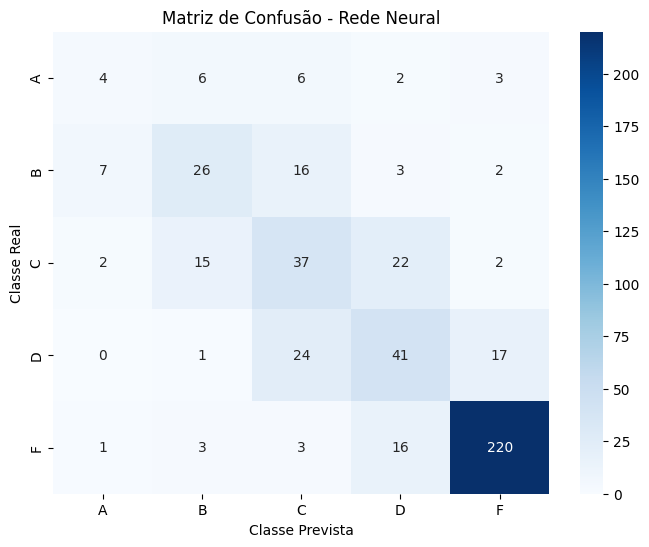

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['A','B','C','D','F'],
    yticklabels=['A','B','C','D','F']
)

plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de Confusão - Rede Neural")

plt.show()

#Conclusão da Matriz de Confusão

###A matriz de confusão demonstrou que a Rede Neural apresentou melhor desempenho na identificação dos estudantes da classe F, obtendo 220 classificações corretas. Observou-se que a maior parte dos erros ocorreu entre classes adjacentes, como B e C ou C e D, indicando que o modelo consegue capturar a ordem natural do desempenho acadêmico. Além disso, houve poucas confusões entre classes extremas, como A e F, sugerindo que a Rede Neural consegue diferenciar adequadamente alunos com desempenhos muito distintos. Contudo, o baixo número de acertos na classe A sugere um possível desbalanceamento do conjunto de dados, favorecendo as classes mais frequentes durante o treinamento.

# 12 — Classification Report

###A matriz de confusão mostrou visualmente onde a Rede Neural está acertando e errando.

###Agora vamos obter métricas mais detalhadas para cada classe:

*  Precision
*  Recall
*  F1-Score
*  Support

In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['A', 'B', 'C', 'D', 'F']
    )
)

              precision    recall  f1-score   support

           A       0.29      0.19      0.23        21
           B       0.51      0.48      0.50        54
           C       0.43      0.47      0.45        78
           D       0.49      0.49      0.49        83
           F       0.90      0.91      0.90       243

    accuracy                           0.68       479
   macro avg       0.52      0.51      0.51       479
weighted avg       0.68      0.68      0.68       479



#Métrica usadas:

### Precision

Responde:

"Quando a Rede Neural disse que era classe A, quantas vezes ela realmente acertou?"

### Recall

Responde:

"De todos os alunos que realmente eram A, quantos a Rede Neural conseguiu encontrar?"

### F1-Score

É um equilíbrio entre Precision e Recall

# Conclusão do Relatório

### O Classification Report demonstrou que a Rede Neural apresentou desempenho elevado na identificação da classe F (F1-score = 0,90), enquanto as classes A, B, C e D obtiveram resultados moderados. Observou-se um forte desbalanceamento no conjunto de dados, com 243 exemplos da classe F e apenas 21 exemplos da classe A. Esse desbalanceamento influenciou diretamente o desempenho do modelo, favorecendo a identificação das classes mais frequentes. Apesar disso, a Rede Neural alcançou uma acurácia geral de aproximadamente 68%, indicando capacidade de capturar padrões relevantes no desempenho acadêmico dos estudantes.